In [8]:
from baseclasses.network import Network
from scipy.optimize import root, minimize

import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Debugging of hydraulics

In [46]:
# Load class instance at crash point
net_id = 'Profile 3'
Kvleak_bool = True
dis_steps = 125
c = 50
N = 27091
pump_type = 'curve'

if N is not None:
    file_name = f"{net_id}_N={N}_Kvleak={Kvleak_bool}_hsteps={dis_steps}_pump={c}kPa_{pump_type}.pkl"
else: 
    file_name = f"{net_id}_Kvleak={Kvleak_bool}_hsteps={dis_steps}_pump={c}kPa_{pump_type}.pkl"

    
# base_dir = os.path.dirname(__file__)
base_dir = os.path.abspath('')

file = os.path.join(base_dir, 'debug', file_name)

with open(file, 'rb') as f:
    state = pickle.load(f)

net = Network.__new__(Network)  # create instance without calling __init__
net.__dict__.update(state)

# Determine N of the crashed state
zero_cols = (net.mflow_all == 0).all(axis=0)
non_zero_cols = ~zero_cols  # flip: True where column is NOT all-zero
idx = non_zero_cols[::-1].argmax()  # first non-zero from the right
N = len(non_zero_cols) - 1 - idx

pipe_ids = np.array(list(net.pipes.keys()))
p = len(pipe_ids)

# Initial guess for the mflows in the pipes
# mflow0 = net.mflow_all[:,N-1] 
# mflow0[mflow0 == 0] = 0.05 # Avoid zero initial guess for better convergence, can be tuned.
mflow0 = np.ones(p)*0.1

active_graph, active_mask = net.update_valves(N)
net.build_loop_matrix(active_graph)

# Reduce and create active incidence matrix
net.incidence_matrix_red = net.incidence_matrix[1:,:]
incidence_matrix_active = net.incidence_matrix_red[:, active_mask]
net.incidence_matrix_active = incidence_matrix_active[~np.all(incidence_matrix_active == 0, axis=1), :]  # Remove zero rows (disconnected nodes)

# Adjust all vectors to active pipes
friction_vector = net.pressure_friction_vector + \
                net.Kp_array + \
                net.inv_Kv_array ** 2

                # inv_Kv_array_debug ** 2
                # np.round(net.inv_Kv_array ** 2)
net.friction_vector_active = friction_vector[active_mask]

net.pressure_elevation_vector_active = net.pressure_elevation_vector[active_mask]
net.pump_coeff_active = net.pump_coeff[active_mask, :]
mflow0_active = mflow0[active_mask]

result = root(net.res, mflow0_active, jac = net.jac, method = 'hybr', tol = 1e-5)
mflow = result.x

# Try it for different rounding of the vector

# Retry with progressively rounded friction vectors if initial solve failed

if result.success == False or (result.x > 0).all():
    # solved = False
    for precision in range(5,0,-1):

        friction_vector = net.pressure_friction_vector + \
                        net.Kp_array + \
                        np.round(net.inv_Kv_array**2,precision)
        net.friction_vector_active = friction_vector[active_mask]
        
        # Solves system of non linear equations using scipy root function
        result = root(net.res, mflow0_active, jac = net.jac, method = 'hybr', tol = 1e-6)

        # Try other root solver
        lm = False
        if result.success == False or (result.x < 0).all():
            result = root(net.res, mflow0_active, jac = net.jac, method = 'lm', tol = 1e-6)
            lm = True

        if result.success == True and (result.x > 0).all():
            solved = True
            print(f'precision {i}')
            if lm:
                print('used Levenbergh Marquardt')
            break
    
    # In case root solving didn't work.
    if not solved: 
        for precision in range(5,0,-1): 
            friction_vector = net.pressure_friction_vector + \
                            net.Kp_array + \
                            np.round(net.inv_Kv_array**2,precision)
            net.friction_vector_active = friction_vector[active_mask]

            result = minimize(
                fun=lambda x: np.sum(net.res(x)**2),
                x0=mflow0_active,
                jac=lambda x: 2 * net.jac(x).T @ net.res(x),  # chain rule: 2 * J^T * F
                method='L-BFGS-B',
                tol=1e-10
            )

            if result.success == True and (result.x > 0).all():
                print(f'timestep {N} used minimization')
                break


elif (result.x > 0).all():
    print(f'Result contains negative flows')

print(result.message)
print(result.success)
print(f'residual sum of result.x {sum(net.res(mflow))}')

# print('mflow0:', mflow0_active)
# print('N:', N)
# print('friction:', sum(net.friction_vector_active))
# print(f'pressure friction {sum(net.pressure_friction_vector)}')
# print(f'Kp array {sum(net.Kp_array)}')
# print('inv_Kv:', sum(net.inv_Kv_array))
# print('loop_matrix shape:', net.loop_matrix_active.shape)
# print('incidence shape:', net.incidence_matrix_active.shape)
# print(f' residual sum saved in net.mflow_all {np.sum(net.res(net.mflow_all[active_mask,N]))}')
# print(f' sum in net.mflow_all {sum(net.mflow_all[:,N])}')
# print(f'Are they equal {result.x == net.mflow_all[active_mask,N]}')
# print(result.x)
# print(f' mflow_all N active_mask {net.mflow_all[active_mask,N]}')

result

precision 5
The solution converged.
True
residual sum of result.x 2.0254053578560125


 message: The solution converged.
 success: True
  status: 1
     fun: [ 0.000e+00  0.000e+00 ... -5.708e-04  3.515e-04]
       x: [ 9.493e-01  9.493e-01 ...  9.630e-03  9.630e-03]
    nfev: 168
    njev: 10
    fjac: [[-1.282e-13  1.719e-14 ... -2.169e-01 -2.667e-01]
           [ 3.173e-03  3.158e-11 ...  8.628e-01  2.794e-01]
           ...
           [-3.012e-03  1.426e-02 ... -1.758e-06  1.505e-05]
           [-5.723e-04  2.709e-03 ... -3.340e-07  2.860e-06]]
       r: [-5.360e+04 -8.331e+03 ...  7.282e-03  1.019e+00]
     qtf: [ 8.671e-02 -6.860e-03 ...  2.431e-08  4.619e-09]

# Looking for reason why the overflow massflow is so much higher. 

In [2]:
dt = 1
benchmark_overflow_dict = {}
opt_overflow_dict = {}

init_points = 5
n_iter = 10
for i in range(1,5):

    thesis_dir = os.path.abspath("")
    bench_folder_name = f'Benchmark_Profile {i}_dt={dt}'
    bench_folder = os.path.join(thesis_dir, 'figures', 'benchmark', bench_folder_name)

    bench_overflow_path = os.path.join(bench_folder, 'hex_consumer_data','overflow.csv')
    bench_overflow_df = pd.read_csv(bench_overflow_path)

    benchmark_overflow_dict[f'Profile {i}'] = bench_overflow_df   

    opt_folder_name = f'Profile {i}_dt={dt}_init_points={init_points}_n_iter={n_iter}'
    opt_folder = os.path.join(thesis_dir, 'figures', 'optimization', opt_folder_name)

    opt_overflow_path = os.path.join(opt_folder, 'hex_consumer_data','overflow.csv')
    opt_overflow_df = pd.read_csv(opt_overflow_path)

    opt_overflow_dict[f'Profile {i}'] = opt_overflow_df

    

In [37]:
n_iter = 10
init_points = 10
dt = 1
i = 4

thesis_dir = os.path.abspath("")
# opt_folder_name = f'Profile {i}_dt={dt}_init_points={init_points}_n_iter={n_iter}'
folder = f'Profile {i}_dt={dt}_init_points={init_points}_n_iter={n_iter}'
opt_folder = os.path.join(thesis_dir, 'figures', 'optimization_set', 'optimization_set_old_weights_+bounds_(5mei)', folder)
overflow_file = os.path.join(opt_folder, 'hex_consumer_data','overflow.csv')
opt_overflow_df = pd.read_csv(overflow_file)
np.sum(opt_overflow_df['mflow'][3600*5:])/19


5.129658079236843

In [16]:
folder = 'NetRut, Kvorg_HEXorg_dt=1_total_time=86400_Tambt=20'
opt_folder = os.path.join(thesis_dir, 'figures', 'simulation', folder)
overflow_file = os.path.join(opt_folder, 'hex_consumer_data','overflow.csv')
opt_overflow_df = pd.read_csv(overflow_file)

folder = 'NetRut, Kvlow_HEXorg_dt=1_total_time=86400_Tambt=20'
opt_folder = os.path.join(thesis_dir, 'figures', 'simulation', folder)
overflow_file_low = os.path.join(opt_folder, 'hex_consumer_data','overflow.csv')
opt_overflow_df_low = pd.read_csv(overflow_file_low)

folder = 'NetRut, Kvlow_HEXorg_cons60kPa_25_0.02_30_dt=1_Tambt=20' 
opt_folder = os.path.join(thesis_dir, 'figures', 'simulation', folder)
overflow_file_constant = os.path.join(opt_folder, 'hex_consumer_data','overflow.csv')
opt_overflow_df_constant_tau30 = pd.read_csv(overflow_file_constant)
# C:\Users\piete\Documents\Delft\TU_Delft\8e jaar\Thesis\Eneco\Eneco - MasterThesis Pieter\Simulatie\thesis\figures\simulation\NetRut, Kvlow_HEXorg_cons60kPa_25_0.02_30_dt=1_total_time=86400_Tambt=20
folder = 'NetRut, Kvlow_HEXorg_cons60kPa_25_0.02_dt=1_total_time=86400_Tambt=20' 
opt_folder = os.path.join(thesis_dir, 'figures', 'simulation', folder)
overflow_file_constant = os.path.join(opt_folder, 'hex_consumer_data','overflow.csv')
opt_overflow_df_constant_tau60 = pd.read_csv(overflow_file_constant)

# Benchmark
folder = 'Benchmark_Profile 1_dt=1'
opt_folder = os.path.join(thesis_dir, 'figures', 'benchmark', folder)
overflow_file_constant = os.path.join(opt_folder, 'hex_consumer_data','overflow.csv')
opt_overflow_df_benchmark = pd.read_csv(overflow_file_constant)


In [17]:
start = 10
end = 21
print(f"low {np.sum(opt_overflow_df_low['mflow'][start*3600:end*3600])/(end-start)} org {np.sum(opt_overflow_df['mflow'][start*3600:end*3600])/(end-start)}, constant tau 60 {np.sum(opt_overflow_df_constant_tau60['mflow'][start*3600:end*3600])/(end-start)}, constant tau 30 {np.sum(opt_overflow_df_constant_tau30['mflow'][start*3600:end*3600])/(end-start)}")
print(f"Benchmark {np.sum(opt_overflow_df_benchmark['mflow'][start*3600:end*3600])/(end-start)}")

print(f"Zero mflow in low: {(opt_overflow_df_low['mflow'] == 0).sum()}")
print(f"Zero mflow in org: {(opt_overflow_df['mflow'] == 0).sum()}")
print(f"Zero mflow in constant 60: {(opt_overflow_df_constant_tau60['mflow'] == 0).sum()}")
print(f"Zero mflow in constant 30: {(opt_overflow_df_constant_tau30['mflow'] == 0).sum()}")
print(f"Zero mflow in benchmark: {(opt_overflow_df_benchmark['mflow'] == 0).sum()}")




# Looked at different Kv values of overflow. But that didn't case a big difference. Also a pump curve less steep or higher does not resolve in a much higher flow, still around 37 l/h, meaning that the overflow reacts each time fast enough to close it
# But looking at the plot of the overflow temperature there doesn't seem to change much between the different kPa. 
# So how is this possible? Is it more closed on micro level and you dont see it on this scale?
# Now I changed Kvs/Kv0 ratio to 25 instead of 50. And lowered h_star to 0.02
# But I don't expect it to make a big difference but still worth a try.

# Last thing I can do is to look at the data Rutger supplied and the beslisdocument to see what the required pressure is if you use Kvs = 0.63 m3/h/sqrt(bar) and that is where it stops

low 36.6105008268041 org 37.017565200782094, constant tau 60 36.7561159384141, constant tau 30 36.781754901607236
Benchmark 42.73096206132049
Zero mflow in low: 22365
Zero mflow in org: 50351
Zero mflow in constant 60: 31074
Zero mflow in constant 30: 28505
Zero mflow in benchmark: 79964


In [52]:
def linear_valve(h, Kvleak_bool = False):
    """
    Returns Kv value of the valve following a linear characteristic
    based on the valve displacement h in [0, 1]. 0 means fully closed, 1 means fully open.
    """
    # self.Kvs = 0.003  # [m3/h/bar^0.5]

    Kvs = 0.000587
    
    Kv0 = Kvs / 25  # same minimum as in equal-percentage
    Kvleak = Kvs / 2000
    
    h_star = 0.05  # lower values of h make the form of the valve deviate from the equal percentage equation.
    
    if h < h_star and Kvleak_bool:
        Kvr = Kv0 + h_star * (Kvs - Kv0)
        Kv = Kvleak + h*(Kvr - Kvleak)/h_star
    else:
        Kv = Kv0 + h * (Kvs - Kv0)
    return Kv

def equal_percentage_valve(h, Kvleak_bool = False):
    """
    Returns Kv value of the valve following an equal percentage characteristic
    based on the valve displacement h in [0, 1]. 0 means fully closed, 1 means fully open.
    """
    # self.Kvs = 0.003  # [m3/h/bar^0.5]

    Kvs = 0.000587
    
    Kv0 = Kvs / 25.0  # minimum Kv at h=0
    Kvleak = Kvs / 2000
    
    h_star = 0.05  # lower values of h make the form of the valve deviate from the equal percentage equation.
    
    if h < h_star and Kvleak_bool:
        Kvr = Kv0 * (Kvs/Kv0)**h_star
        Kv = Kvleak * (Kvr/Kvleak)**(h/h_star)
    else:
        Kv = Kv0 * (Kvs/Kv0)**h
    return Kv


# print(f'linear: {linear_valve(h, Kvleak_bool=True)}')
# print(f'equal percentage: {equal_percentage_valve(h)}')

40796.90149663871

Lets say that you want to reach the average flow of 140 L/h for the setpoint of 55 degrees. If you use the linear valve (with already the Kv0 increase as it is now divided by 25 and also h_star = 0.02) the following amount of pressure do you need to constantly provide to produce a 140/3600 kg/s.

In [72]:
mflow = 140/3600 # kg/s
h1 = 0.033
h2 = 0.15
h3 = 0.20
h4 = 0.25

pressure = 40e3

print(f'Pressure drop over only the bypass valve, but this is not feasible as during periods of high demand pressure drop over the pipes increase significantly.' + '\n'
'Also the overflow almost never comes with a h displacement above 0.2')
print(f' h = {h1}, with dp = {np.round((mflow/linear_valve(h1))**2)/1e3} kPa, with 80 kPa this is the mass flow: {np.round(np.sqrt(pressure)*linear_valve(h1)*3600)} L/h')
print(f' h = {h2}, with dp = {np.round((mflow/linear_valve(h2))**2)/1e3} kPa, with 80 kPa this is the mass flow: {np.round(np.sqrt(pressure)*linear_valve(h2)*3600)} L/h')
print(f' h = {h3}, with dp = {np.round((mflow/linear_valve(h3))**2)/1e3} kPa, with 80 kPa this is the mass flow: {np.round(np.sqrt(pressure)*linear_valve(h3)*3600)} L/h')
print(f' h = {h4}, with dp = {np.round((mflow/linear_valve(h4))**2)/1e3} kPa, with 80 kPa this is the mass flow: {np.round(np.sqrt(pressure)*linear_valve(h4)*3600)} L/h')



Pressure drop over only the bypass valve, but this is not feasible as during periods of high demand pressure drop over the pipes increase significantly.
Also the overflow almost never comes with a h displacement above 0.2
 h = 0.033, with dp = 854.238 kPa, with 80 kPa this is the mass flow: 30.0 L/h
 h = 0.15, with dp = 129.64 kPa, with 80 kPa this is the mass flow: 78.0 L/h
 h = 0.2, with dp = 81.545 kPa, with 80 kPa this is the mass flow: 98.0 L/h
 h = 0.25, with dp = 55.983 kPa, with 80 kPa this is the mass flow: 118.0 L/h


In [ ]:
(0.008715250939171262/2.75615e-05)**2
linear_valve(0.033333333333, Kvleak_bool=False)

print(f'Kvleak True {(0.008715250939171262/linear_valve(0.033333333333, Kvleak_bool=True))**2}')
print(f'Kvleak False {(0.008715250939171262/linear_valve(0.033333333333, Kvleak_bool=False))**2}')

print(f' Kvleak true massflow: {np.sqrt(100e3)*linear_valve(0.033333,Kvleak_bool=True)*3600}')
print(f' Kvleak false massflow: {np.sqrt(100e3)*linear_valve(0.033333,Kvleak_bool=False)*3600}')

Kvleak True 103425.24367322952
Kvleak False 79471.59431325787
 Kvleak true massflow: 30.85068594729452
 Kvleak false massflow: 35.19441416857557


# Determining good cost function parameters

In [9]:
from BayesianOptimization import softrelu

thesis_dir = os.path.abspath("")

number_of_tests = 24

Tr_mean = np.zeros(number_of_tests) # over time
Ts_mean = np.zeros(number_of_tests) # over time
Tr_relu_mean = np.zeros(number_of_tests)

Q_response_tot = np.zeros(number_of_tests) # over floor
Q_response_mean = np.zeros(number_of_tests) # over time 
Q_response_max = [] # per floor

dQ_tot = np.zeros(number_of_tests)         # tot
dQ_mean = np.zeros(number_of_tests)   # per time
dQ_max = []     # per floor 

for i in range(0,number_of_tests):
    folder = f'test_{1+i}_dt=1_Tambt=20'
    opt_folder = os.path.join(thesis_dir, 'figures', 'simulation', folder)
    overflow_file = os.path.join(opt_folder, 'simulation_data','Node_temp.csv')
    opt_overflow_df = pd.read_csv(overflow_file)

    warmup_period = 4.5 #h 
    length_of_simulation = len(opt_overflow_df['Node 1.1'])
    warmup_steps = int(warmup_period / 24 * length_of_simulation)

    T_s = opt_overflow_df['Node 1.1']
    T_r = opt_overflow_df['Node 1.6']

    total_heat_demand = np.zeros(23)
    total_heat_supply = np.zeros(23)

    total_heat_demand_time = np.zeros_like(T_r)

    Q_response = np.zeros(23)

    for hex_idx in range(1,24):

        hex_file = os.path.join(opt_folder, 'hex_consumer_data', f'Hex {hex_idx}.csv')
        hex = pd.read_csv(hex_file)
                  
        Q_d = hex['Q_d'].values
        Q_supply = hex['Q_supply'].values

        total_heat_demand[hex_idx-1] = np.sum(Q_d)
        total_heat_supply[hex_idx-1] = np.sum(Q_supply)

        total_heat_demand_time += Q_d

        # Determine Qresponse       
        dt = 1
        two_min = int(120/dt) # Number of timesteps in 2 minutes
        for idx in range(len(total_heat_demand_time) - 1 - two_min):

            change_binary = (np.tanh(Q_d[idx+1] - Q_d[idx] - 100) + 1)/2  # indicating whether there is a change in heat demand, mapping it to zero or one, by subtracting -100 zero is really zero.     
            
            # how well it responded within 2 minutes based on how close the watts are. 
            Q_response_two_min = Q_d[idx+1:idx+1+two_min] - Q_supply[idx+1:idx+1+two_min]
            
            scaling_factor = 300 / dt # to prevent numerical overflow
            Q_response_relu = softrelu(Q_response_two_min/scaling_factor)*scaling_factor # relu to only look at the positive difference
            
            Q_response[hex_idx-1] += change_binary * np.sum(Q_response_relu) * dt


    
    Ts_mean[i] = np.mean(T_s[warmup_steps:])
    Tr_mean[i] = np.mean(T_r[warmup_steps:])
    Tr_relu_mean[i] = np.mean((np.exp(-total_heat_demand_time[warmup_steps:]/1e5)*T_r[warmup_steps:])) # Only looking at moments when there is no heat demand by applying exp(-Q_d/1e5) 

    dQ_tot[i] = np.sum(total_heat_demand - total_heat_supply)
    dQ_mean[i] = np.mean(total_heat_demand - total_heat_supply)
    tuple_max = (max(total_heat_demand - total_heat_supply), np.argmax(total_heat_demand - total_heat_supply))
    dQ_max.append(tuple_max)
    
    Q_response_tot[i] = np.sum(Q_response)
    Q_response_mean[i] = np.mean(Q_response) # over floor 
    tuple_max_Qresponse = (np.max(Q_response), np.argmax(Q_response))
    Q_response_max.append(tuple_max_Qresponse)


In [11]:
# Print header
header = (
    f"{'Test':<6}"
    f"{'Ts_mean':>12}"
    f"{'Tr_mean':>12}"
    f"{'Tr_relu':>12}"
    f"{'dQ_tot[kJ]':>14}"
    f"{'dQ_mean[kJ]':>15}"
    f"{'dQ_max[kJ]':>18}"
    f"{'Q_resp_tot[kJ]':>18}"
    f"{'Q_resp_mean[kJ]':>19}"
    f"{'Q_resp_max[kJ]':>22}"
)

print(header)
print("-" * len(header))

number_of_tests = 24
# Print rows
for i in range(number_of_tests):

    dq_max_val = np.round(dQ_max[i][0] / 1e3, 2)
    dq_max_floor = dQ_max[i][1]

    qresp_max_val = np.round(Q_response_max[i][0] / 1e3, 2)
    qresp_max_floor = Q_response_max[i][1]

    print(
        f"{i+1:<6}"
        f"{Ts_mean[i]:>12.2f}"
        f"{Tr_mean[i]:>12.2f}"
        f"{Tr_relu_mean[i]:>12.2f}"
        f"{np.round(dQ_tot[i]/1e3, 2):>14.2f}"
        f"{np.round(dQ_mean[i]/1e3, 2):>15.2f}"
        f"{f'{dq_max_val} ({dq_max_floor})':>18}"
        f"{np.round(Q_response_tot[i]/1e3, 2):>18.2f}"
        f"{np.round(Q_response_mean[i]/1e3, 2):>19.2f}"
        f"{f'{qresp_max_val} ({qresp_max_floor})':>22}"
    )

    if (i + 1) % 4 == 0:
        print()

Test       Ts_mean     Tr_mean     Tr_relu    dQ_tot[kJ]    dQ_mean[kJ]        dQ_max[kJ]    Q_resp_tot[kJ]    Q_resp_mean[kJ]        Q_resp_max[kJ]
----------------------------------------------------------------------------------------------------------------------------------------------------
1            65.00       29.73       29.44      55735.13        2423.27      9217.48 (22)          48556.13            2111.14           5326.2 (22)
2            60.00       30.60       30.26      89896.02        3908.52     12638.15 (22)          64826.32            2818.54          7328.75 (22)
3            60.04       30.63       30.31      72049.07        3132.57     11114.19 (22)          53897.00            2343.35          6409.57 (22)
4            60.06       30.61       30.30      68451.49        2976.15     10648.91 (22)          51821.98            2253.13           6104.6 (22)

5            65.00       21.37       20.44       8362.25         363.58        395.25 (4)          26754.

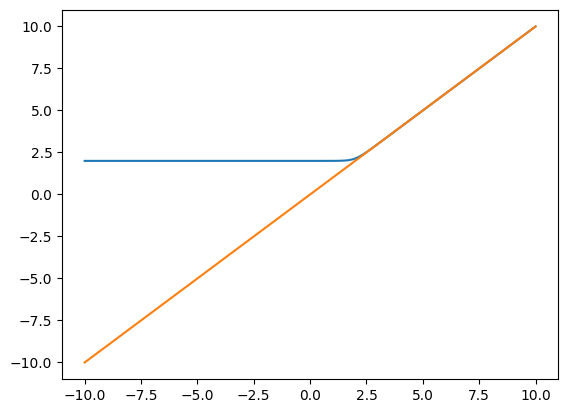

In [134]:
def softrelu(x, alpha=10):
    return np.log(1 + np.exp(alpha * (x-2))) / alpha + 2


test = np.linspace(-10,10,100)
plt.plot(test, softrelu(test, alpha=5))
plt.plot(test,test, label='identity')

# Old cost function (10 May)

In [6]:
warmup_period = 4.5 #h 
length_of_simulation = len(T_overflow)
warmup_steps = int(warmup_period / 24 * length_of_simulation)

### Return temperature term ###
# Hot well saved in ground is 15-18 degrees, cold well 5-8 (literature survey Femke). 
# c_p = 4184 # J/ kg K
# E_price = 60 * 1e-6 / 3600 # Euro / MWh -> Euro / W s 

# T_source = 273.15 + 8   # aquifer target [K] — what you cool TO
# T_sink   = 273.15 + T_r[warmup_steps:]  # return water [K]   — what you cool FROM
# COP_ideal = T_source / (T_sink - T_source)

# eta = 0.5
# COP_real = eta * COP_ideal

# P_used = (T_sink - T_source)* mflow_r[warmup_steps:] * c_p / COP_real * self.dt
# term_Tr = np.sum(np.exp(-total_heat_demand[warmup_steps:]/1e5) * E_price * P_used) # Only looking at moments when there is no heat demand by applying exp(-Q_d/1e5) 
term_Tr = self.w_Tr * np.mean((np.exp(-total_heat_demand[warmup_steps:]/1e5)*T_r[warmup_steps:])**2) # Only looking at moments when there is no heat demand by applying exp(-Q_d/1e5) 

### Heat demand difference term ###      
heat_demand_idx = [idx for idx,i in enumerate(total_heat_demand) if i>0] # Obtain all idx for total heat demand above zero 

term_Q = self.dict_w_Q[self.profile] * np.mean((total_heat_demand[heat_demand_idx] - total_heat_supply[heat_demand_idx])**2)

### Heat demand waiting time response term ###
term_Qrespond = self.dict_w_Qrespond[self.profile] * Q_respond # So averge delta_Q within those 2 minutes

### Supply term delivered ###
# eta_boiler = 0.6
# P_used_Ts = eta_boiler * mflow_r[warmup_steps:] * (T_s[warmup_steps:] - 30) * c_p * self.dt
# term_Ts = np.sum(P_used_Ts * E_price) 
        
term_Ts = self.w_Ts * np.mean(T_s[warmup_steps:]**2)

### Difference in supply term ###
term_dTs = self.w_dTs * np.sum(np.diff(T_s[warmup_steps:])**2)

### Regularization ###

# And their weights
        self.w_Tr = 0.5
        self.w_Ts = 0.1
        self.w_dTs = 0.5

        self.dict_w_Q = {
            'Profile 1': 1.5*0.4e-7,
            'Profile 2': 1.5*0.4e-6,
            'Profile 3': 1.5*0.1e-5,
            'Profile 4': 1.5*0.1e-4}
        
        self.dict_w_Qrespond = {
            'Profile 1': 2*0.08e-3,
            'Profile 2': 2*0.1e-3,
            'Profile 3': 2*0.1e-3,
            'Profile 4': 2*0.1e-3
        }

11.432304425935

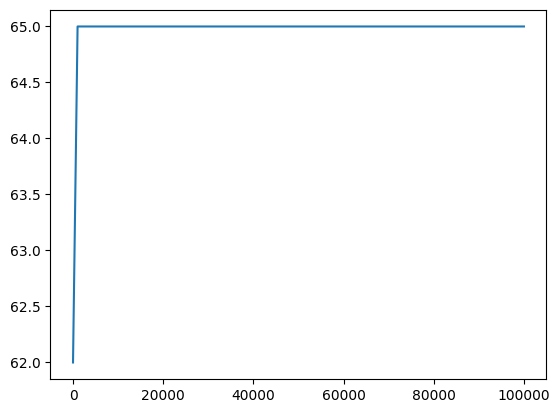

In [13]:
import numpy as np 

def softplus(x, k):
    """Numerically stable softplus: (1/k) * log(1 + exp(k*x))"""
    return np.logaddexp(0, k * x) / k

def smooth_clip(x, T_min, T_max, k):
    """
    Smooth double-sided clamp of x to [T_min, T_max].
    k controls sharpness: large k → hard clip, small k → soft/rounded.
    """
    lower  = T_min + softplus(x - T_min, k)          # soft lower bound
    clipped = T_max - softplus(T_max - lower, k)      # soft upper bound
    return clipped

def T_supply_smooth(Q_demand, theta_1, theta_2, theta_3, T_min=60.0, T_max=65.0):
    """
    Smooth clipped linear supply temperature as function of heat demand.

    theta_1 : base temperature offset [°C]
    theta_2 : slope [°C/W]
    theta_3 : sharpness of the clipping [1/°C], larger = sharper corners
    """
    x = theta_1 + theta_2 * Q_demand
    return smooth_clip(x, T_min, T_max, k=theta_3)

Q = np.linspace(0,100e3, 100)

T_supply = T_supply_smooth(Q, 62, 64, 10)

plt.plot(Q,T_supply)

In [18]:
r_inner = 0.01
r_outer = 0.0135  
k = 0.3
rho_water = 1000
c_p = 4181



r_inner**2 / r_outer **2

0.5486968449931413